# APRENDIZAJE AUTOMÁTICO
# Práctica 4: Regresión Logística Multiclase y Redes Neuronales
### Autor: Sanchez Sarsa, Eduardo
### NIP:   901813
### Fecha: 27-02-2026
---

---
## 0. Carga de datos de MNIST

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Load data from https://www.openml.org/
dataset = "mnist_784"
X, y = fetch_openml(dataset, version=1, return_X_y=True, as_frame=False, parser="pandas")
X = X / 255.0  # Escalar los datos entre 0 y 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, shuffle=False)

print('X_train.shape:', X_train.shape)
print('y_train.shape:', y_train.shape)
print('X_test.shape:', X_test.shape)
print('y_test.shape:', y_test.shape)


X_train.shape: (60000, 784)
y_train.shape: (60000,)
X_test.shape: (10000, 784)
y_test.shape: (10000,)


.......

## 1. Curvas de aprendizaje

Tamanos evaluados: [ 4800  9600 14400 19200 24000 28800 33600 38400 43200 48000]
Accuracy media entrenamiento: [1.     1.     0.9912 0.9715 0.9597 0.9525 0.9475 0.9446 0.9426 0.9433]
Accuracy media validacion: [0.8626 0.8642 0.8659 0.8848 0.8951 0.9004 0.9066 0.9092 0.9124 0.9137]


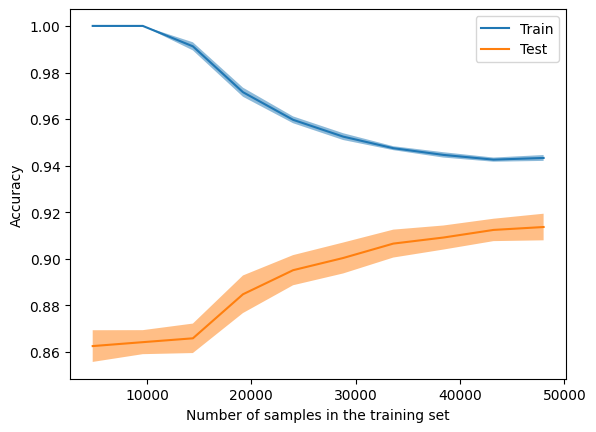

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LearningCurveDisplay, StratifiedKFold, learning_curve
import matplotlib.pyplot as plt

logit_basico = LogisticRegression(
    penalty=None,            # Sin regularizacion
    max_iter=300,
    random_state=28,
)

train_sizes = np.linspace(0.1, 1.0, 10)

sizes, train_scores, test_scores = learning_curve(estimator=logit_basico, X=X_train, y=y_train, train_sizes=train_sizes,
    cv=5, scoring="accuracy", n_jobs=-1)
LearningCurveDisplay(train_sizes=sizes, train_scores=train_scores, test_scores=test_scores, score_name="Accuracy").plot()

train_mean = train_scores.mean(axis=1)
val_mean = test_scores.mean(axis=1)
val_std = test_scores.std(axis=1)

# Gráficas generadas con inteligencia artificial.

# plt.figure(figsize=(9, 5))
# plt.plot(sizes, train_mean, "o-", label="Entrenamiento")
# plt.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
# plt.plot(sizes, val_mean, "o-", label="Validacion (CV)")
# plt.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
# plt.xlabel("Numero de muestras de entrenamiento")
# plt.ylabel("Accuracy")
# plt.title("Curvas de aprendizaje - Regresion Logistica sin regularizacion")
# plt.grid(alpha=0.25)
# plt.legend()
# plt.show()

print("Tamanos evaluados:", sizes.astype(int))
print("Accuracy media entrenamiento:", np.round(train_mean, 4))
print("Accuracy media validacion:", np.round(val_mean, 4))

---
### Conclusiones:
En las curvas podemos ver, un efecto claro, cuanto menos datos datos, más sobreajusta nuestro modelo, vemos que hay gran diferencia entre *'accuracy'* en *test* y *train*.
Lo cual es muy coherente, vemos que al aumentar las muestras de train, la diferencia se reduce (se va reduciendo el sobreajuste) y el *'accuracy'* va bajando, hasta probablemente estabilizarse en torno al 0.95

Esto tiene mucho sentido, ya que el modelo de regresión logística básica sin expansión de atributos tiene muchas limitaciones y por lo general es un modelo que necesita algún ajuste más (como expansión de atributos y regularización). A priori, veríamos un *accuracy* en test de alreadedore de 0.91, lo cual para este primer modelo es aceptable.

## 2. Regresión logística.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

Cs = np.logspace(-2, 6, 5)
Cs = [0.01, 1, 10]
solvers_reg = ["lbfgs", "saga"]
cv = KFold(n_splits=5, shuffle=True, random_state=28)

grid_reg = GridSearchCV(
    estimator=Pipeline(
        [
            # ("poly", PolynomialFeatures(degree=2)),
            ("logreg", LogisticRegression(max_iter=500, random_state=28, tol=0.01)),
        ]
    ),
    param_grid={"logreg__solver": solvers_reg, "logreg__C": Cs},
    scoring="accuracy",
    # cv=cv,
    return_train_score=True,
    n_jobs=-1,
)

grid_reg.fit(X_train, y_train)

cv_results = grid_reg.cv_results_
df_cv = pd.DataFrame(
    {
        "solver": np.array(cv_results["param_logreg__solver"], dtype=str),
        "C": np.array(cv_results["param_logreg__C"], dtype=float),
        "train_accuracy": cv_results["mean_train_score"],
        "val_accuracy": cv_results["mean_test_score"],
    }
)


In [4]:
df_cv.sort_values(by="val_accuracy", ascending=False, inplace=True)
df_cv

,solver,C,train_accuracy,val_accuracy
3,saga,1.00,0.937683,0.921133
5,saga,10.00,0.939150,0.920700
1,saga,0.01,0.917600,0.912183
2,lbfgs,1.00,0.838200,0.836483
4,lbfgs,10.00,0.838204,0.836450
0,lbfgs,0.01,0.837692,0.835733


Mejores hiperparametros (Logistic Regression): {'logreg__C': 1, 'logreg__solver': 'saga'}
Accuracy CV (validacion): 0.9211
Accuracy train (modelo ganador): 0.9377
Brecha train-validacion: 0.0166
Accuracy en test: 0.9258

Informe de clasificacion en test (Logistic Regression):

              precision    recall  f1-score   support

           0     0.9523    0.9786    0.9653       980
           1     0.9627    0.9780    0.9703      1135
           2     0.9301    0.9021    0.9159      1032
           3     0.9039    0.9129    0.9084      1010
           4     0.9357    0.9338    0.9348       982
           5     0.8971    0.8700    0.8833       892
           6     0.9441    0.9520    0.9480       958
           7     0.9311    0.9202    0.9256      1028
           8     0.8822    0.8840    0.8831       974
           9     0.9094    0.9158    0.9126      1009

    accuracy                         0.9258     10000
   macro avg     0.9249    0.9247    0.9247     10000
weighted avg     0

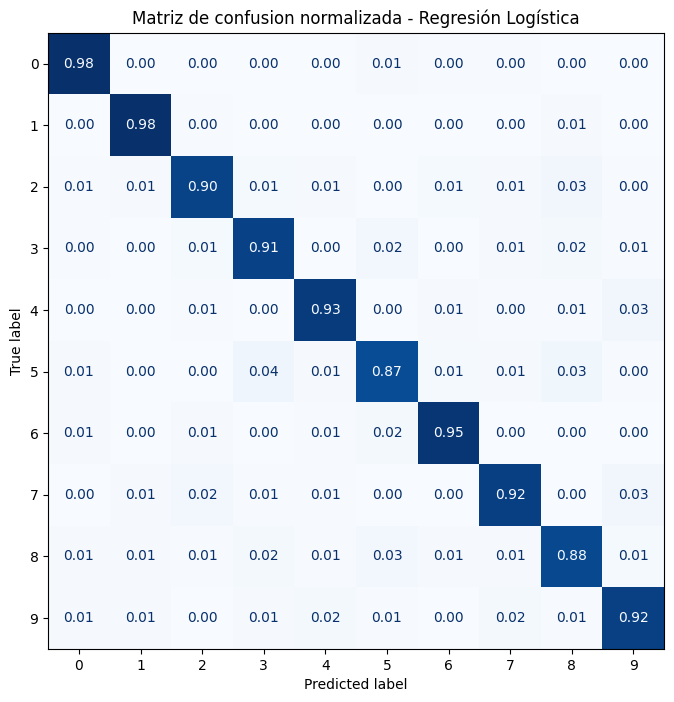

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import classification_report, accuracy_score

best_logreg = grid_reg.best_estimator_
y_pred_logreg = best_logreg.predict(X_test)

test_acc_logreg = accuracy_score(y_test, y_pred_logreg)
best_params_logreg = grid_reg.best_params_
best_idx_logreg = grid_reg.best_index_
best_train_acc_logreg = grid_reg.cv_results_["mean_train_score"][best_idx_logreg]
best_val_acc_logreg = grid_reg.best_score_
gap_logreg = best_train_acc_logreg - best_val_acc_logreg

print("Mejores hiperparametros (Logistic Regression):", best_params_logreg)
print(f"Accuracy CV (validacion): {best_val_acc_logreg:.4f}")
print(f"Accuracy train (modelo ganador): {best_train_acc_logreg:.4f}")
print(f"Brecha train-validacion: {gap_logreg:.4f}")
print(f"Accuracy en test: {test_acc_logreg:.4f}\n")

print("Informe de clasificacion en test (Logistic Regression):\n")
print(classification_report(y_test, y_pred_logreg, digits=4))

labels = np.array(best_logreg.classes_)
cm_norm = confusion_matrix(y_test, y_pred_logreg, labels=labels, normalize="true")

fig, ax = plt.subplots(figsize=(8, 8))
dispConfMatrix = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
dispConfMatrix.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
ax.set_title("Matriz de confusion normalizada - Regresión Logística")
plt.show()

## Conclusiones:
Vemos un modelo ciertamente correcto, de los 10 números que tenemos, 8 de ellos supera el 90% de predicción correcta.

Los peores números que vemos son el 5 y 8, números que parecen costarle al modelo, lo cual, es normal, teniendo en cuenta el simil que tienen el 5 y el 3, y el 5 y 8, que son los más confundidos, para este modelo no muestro los ejemplos, pero para el resto sí.

La clase que peor f1-score tiene es el 8, pero estando prácticamente igual que el 5, teniendo el 5 el peor recall que nos indica que de todos los 5 reales, ha tenido el peor resultado al intentar clasificarlos.
El caso de este número 5 se podría explicar aparte de por la simplicidad del modelo, ya que no se le ha aplicado la expansión de atributos (el proceso era demasiado costoso en tiempo, aunque me había planteado realizar una expansión de grado 2), el número 5 es también el que menos muestras de test tiene, lo que podría ser un factor en los resultados.

## 3. Perceptrón sin capa oculta

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

# Perceptron sin capa oculta: hidden_layer_sizes=()
base_mlp0 = MLPClassifier(
    hidden_layer_sizes=(),
    max_iter=80,
    early_stopping=False,
    validation_fraction=0.1,
    tol=1e-1,
    n_iter_no_change=5,
    random_state=28,
)

param_grid_mlp0 = {
    "mlp__solver": ["adam", "sgd"],
    "mlp__alpha": [1e-5, 1e-4, 1e-3],
    "mlp__learning_rate_init": [1e-3, 5e-3],
}

cv_mlp0 = StratifiedKFold(n_splits=2, shuffle=True, random_state=28)

grid_mlp0 = GridSearchCV(
    estimator=Pipeline([("mlp", base_mlp0)]),
    param_grid=param_grid_mlp0,
    scoring="accuracy",
    cv=cv_mlp0,
    return_train_score=True,
    n_jobs=-1,
)

grid_mlp0.fit(X_train, y_train)

cv_results_mlp0 = pd.DataFrame(
    {
        "solver": np.array(grid_mlp0.cv_results_["param_mlp__solver"], dtype=str),
        "alpha": np.array(grid_mlp0.cv_results_["param_mlp__alpha"], dtype=float),
        "learning_rate_init": np.array(grid_mlp0.cv_results_["param_mlp__learning_rate_init"], dtype=float),
        "train_accuracy": grid_mlp0.cv_results_["mean_train_score"],
        "val_accuracy": grid_mlp0.cv_results_["mean_test_score"],
    }
)

cv_results_mlp0.sort_values(by="val_accuracy", ascending=False, inplace=True)
cv_results_mlp0

,solver,alpha,learning_rate_init,train_accuracy,val_accuracy
6,adam,0.00010,0.005,0.933450,0.918700
2,adam,0.00001,0.005,0.933467,0.918683
10,adam,0.00100,0.005,0.933250,0.918650
8,adam,0.00100,0.001,0.917900,0.912167
0,adam,0.00001,0.001,0.917933,0.912150
4,adam,0.00010,0.001,0.917933,0.912133
11,sgd,0.00100,0.005,0.896817,0.893967
3,sgd,0.00001,0.005,0.896817,0.893967
7,sgd,0.00010,0.005,0.896817,0.893967
1,sgd,0.00001,0.001,0.867433,0.864867


Mejores hiperparametros (MLP sin capa oculta): {'mlp__alpha': 0.0001, 'mlp__learning_rate_init': 0.005, 'mlp__solver': 'adam'}
Accuracy CV (validacion): 0.9187
Accuracy train (modelo ganador): 0.9335
Brecha train-validacion: 0.0147
Accuracy en test: 0.9252

Informe de clasificacion en test (MLP sin capa oculta):

              precision    recall  f1-score   support

           0     0.9544    0.9816    0.9678       980
           1     0.9787    0.9718    0.9752      1135
           2     0.9375    0.9012    0.9190      1032
           3     0.8953    0.9228    0.9088      1010
           4     0.9483    0.9155    0.9316       982
           5     0.9401    0.8442    0.8895       892
           6     0.9264    0.9593    0.9426       958
           7     0.9062    0.9397    0.9226      1028
           8     0.8422    0.9097    0.8746       974
           9     0.9270    0.8940    0.9102      1009

    accuracy                         0.9252     10000
   macro avg     0.9256    0.9240  

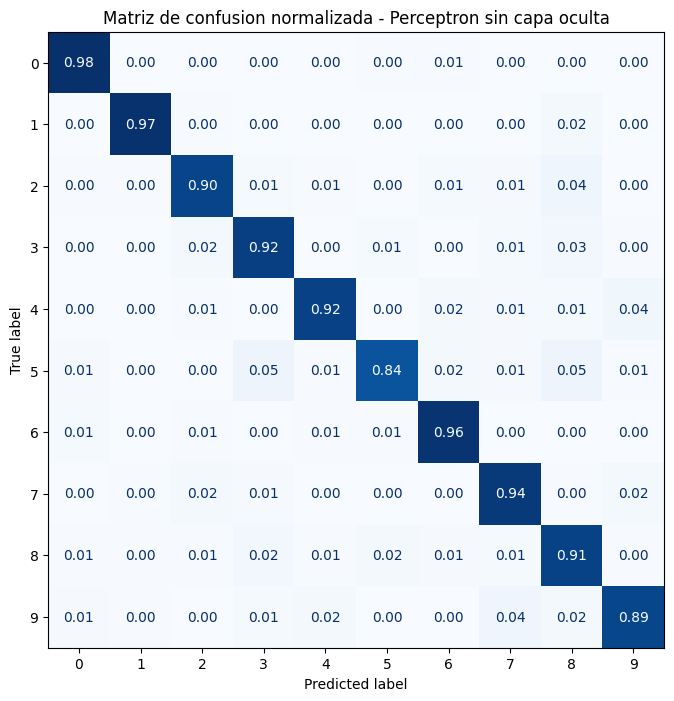

Digitos mas problematicos (menor recall):
- Digito 5: recall=0.8442
- Digito 9: recall=0.8940
- Digito 2: recall=0.9012

Confusiones mas habituales (porcentaje sobre el digito real):
- 5 -> 3: 4.93%
- 5 -> 8: 4.82%
- 9 -> 7: 4.16%
- 2 -> 8: 3.97%
- 4 -> 9: 3.67%
- 3 -> 8: 2.57%
- 8 -> 3: 2.36%
- 5 -> 6: 2.13%


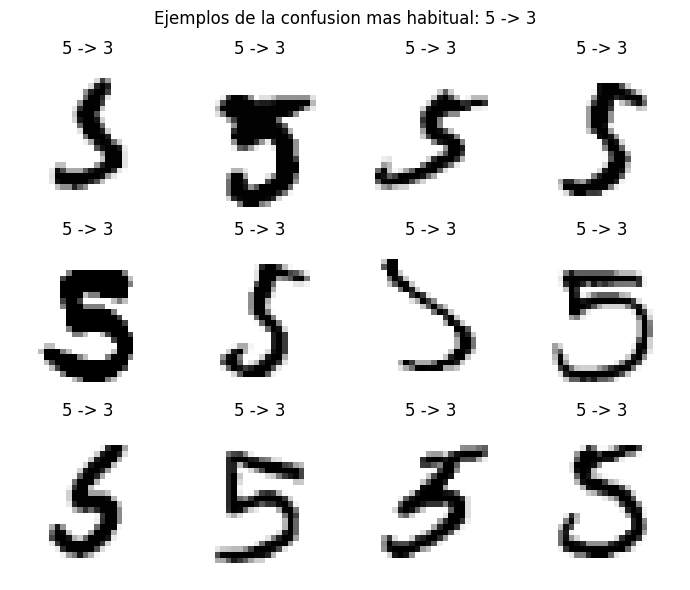

In [ ]:
from sklearn.metrics import confusion_matrix

best_mlp0 = grid_mlp0.best_estimator_
y_pred_test_mlp0 = best_mlp0.predict(X_test)

test_acc_mlp0 = accuracy_score(y_test, y_pred_test_mlp0)
best_params_mlp0 = grid_mlp0.best_params_
best_idx_mlp0 = grid_mlp0.best_index_
best_train_acc_mlp0 = grid_mlp0.cv_results_["mean_train_score"][best_idx_mlp0]
best_val_acc_mlp0 = grid_mlp0.best_score_
gap_mlp0 = best_train_acc_mlp0 - best_val_acc_mlp0

print("Mejores hiperparametros (MLP sin capa oculta):", best_params_mlp0)
print(f"Accuracy CV (validacion): {best_val_acc_mlp0:.4f}")
print(f"Accuracy train (modelo ganador): {best_train_acc_mlp0:.4f}")
print(f"Brecha train-validacion: {gap_mlp0:.4f}")
print(f"Accuracy en test: {test_acc_mlp0:.4f}\n")

print("Informe de clasificacion en test (MLP sin capa oculta):\n")
print(classification_report(y_test, y_pred_test_mlp0, digits=4))

labels = np.array(best_mlp0.classes_)
cm_norm = confusion_matrix(y_test, y_pred_test_mlp0, labels=labels, normalize="true")

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
ax.set_title("Matriz de confusion normalizada - Perceptron sin capa oculta")
plt.show()

###############################################
# Código generado con inteligencia artificial #
###############################################

recalls = np.diag(cm_norm)
worst_idx = np.argsort(recalls)[:3]
print("Digitos mas problematicos (menor recall):")
for i in worst_idx:
    print(f"- Digito {labels[i]}: recall={recalls[i]:.4f}")

cm_off = cm_norm.copy()
np.fill_diagonal(cm_off, 0.0)
pairs = []
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j:
            pairs.append((cm_off[i, j], labels[i], labels[j]))
pairs.sort(key=lambda x: x[0], reverse=True)

print("\nConfusiones mas habituales (porcentaje sobre el digito real):")
for rate, true_label, pred_label in pairs[:8]:
    print(f"- {true_label} -> {pred_label}: {100 * rate:.2f}%")

# Visualizacion de ejemplos reales de la confusion mas frecuente
top_rate, top_true, top_pred = pairs[0]
mask = (y_test == top_true) & (y_pred_test_mlp0 == top_pred)
idx = np.where(mask)[0][:12]

if len(idx) > 0:
    fig, axes = plt.subplots(3, 4, figsize=(7, 6))
    for ax, k in zip(axes.ravel(), idx):
        ax.imshow(X_test[k].reshape(28, 28), cmap="gray_r")
        ax.set_title(f"{y_test[k]} -> {y_pred_test_mlp0[k]}")
        ax.axis("off")
    fig.suptitle(f"Ejemplos de la confusion mas habitual: {top_true} -> {top_pred}")
    plt.tight_layout()
    plt.show()

## Conclusiones:

Al ver la matriz de confusión y compararla con el modelo anterior, vemos que prácticamente obtenemos resultados iguales,
el número 5 tiene un peor acierto que en el modelo anterior, y en vez de predecir mal el número 8, predice un poco peor el número 9 (teniendo como referencia ese 90% de acierto en la predicción).

El recall del número 5 baja casi 3 puntos, si bien en los 12 números que se muestran podemos ver alguno que no parece un 5, muchos otros sí.

Este modelo, al no tener capas ocultas, se comporta casi como una regresión logística, al fin y al cabo, ambos modelos son lineales sin el uso de expansión de atributos y de capas ocultas.

Vemos resultados parecidos porque usamos solvers casi idénticos que tienden a converger en un mínimo global.

## 4. Perceptrón multicapa

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.base import clone
from sklearn.model_selection import ParameterGrid, StratifiedKFold, cross_validate
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

# Probamos con 'adam' primero.
base_mlpm = MLPClassifier(
    activation="relu",
    solver="adam",
    max_iter=80,
    early_stopping=False,
    validation_fraction=0.1,
    tol=1e-1,
    n_iter_no_change=5,
    random_state=28,
)

param_dist_mlpm = {
    "mlp__hidden_layer_sizes": [(128,), (256,), (128, 64), (256, 128), (300, 150)],
    "mlp__alpha": [1e-5, 1e-4, 5e-4, 1e-3],
    "mlp__learning_rate_init": [5e-4, 1e-3, 2e-3],
}

cv_mlpm = StratifiedKFold(n_splits=3, shuffle=True, random_state=28)

rows_mlpm = []
# Variables para quedanos con el mejor modelo basado en la accuracy de validacion
best_val_acc = -np.inf
best_train_acc = None
best_params_mlpm = None

for params in ParameterGrid(param_dist_mlpm):
    model = Pipeline([("mlp", clone(base_mlpm))])
    model.set_params(**params)
    scores = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv_mlpm,
        scoring="accuracy",
        return_train_score=True,
        n_jobs=-1,
    )

    mean_train = float(np.mean(scores["train_score"]))
    mean_val = float(np.mean(scores["test_score"]))
    rows_mlpm.append({
        "hidden_layers": str(params["mlp__hidden_layer_sizes"]),
        "alpha": float(params["mlp__alpha"]),
        "learning_rate_init": float(params["mlp__learning_rate_init"]),
        "train_accuracy": mean_train,
        "val_accuracy": mean_val,
    })
    # Actualizar el mejor modelo basado en la accuracy de validacion
    if mean_val > best_val_acc:
        best_val_acc = mean_val
        best_train_acc = mean_train
        best_params_mlpm = params

best_mlpm = Pipeline([("mlp", clone(base_mlpm))])
best_mlpm.set_params(**best_params_mlpm)
best_mlpm.fit(X_train, y_train)

cv_results_mlpm_adam = pd.DataFrame(rows_mlpm)

cv_results_mlpm_adam.sort_values(by="val_accuracy", ascending=False, inplace=True)
cv_results_mlpm_adam.head(10)

,hidden_layers,alpha,learning_rate_init,train_accuracy,val_accuracy
14,"(300, 150)",0.00001,0.002,0.996633,0.975900
56,"(256, 128)",0.00100,0.002,0.997025,0.975633
50,"(256,)",0.00100,0.002,0.996675,0.975550
28,"(300, 150)",0.00010,0.001,0.996742,0.975533
20,"(256,)",0.00010,0.002,0.996567,0.975483
5,"(256,)",0.00001,0.002,0.996808,0.975450
44,"(300, 150)",0.00050,0.002,0.995675,0.975433
13,"(300, 150)",0.00001,0.001,0.996742,0.975250
43,"(300, 150)",0.00050,0.001,0.996450,0.975167
35,"(256,)",0.00050,0.002,0.996650,0.974867


Mejores hiperparametros (MLP multicapa): {'mlp__alpha': 1e-05, 'mlp__hidden_layer_sizes': (300, 150), 'mlp__learning_rate_init': 0.002}
Accuracy CV (validacion): 0.9759
Accuracy train (modelo ganador): 0.9966
Brecha train-validacion: 0.0207
Accuracy en test: 0.9761

Informe de clasificacion en test (MLP multicapa):

              precision    recall  f1-score   support

           0     0.9938    0.9857    0.9898       980
           1     0.9964    0.9815    0.9889      1135
           2     0.9623    0.9903    0.9761      1032
           3     0.9725    0.9792    0.9758      1010
           4     0.9872    0.9460    0.9662       982
           5     0.9720    0.9731    0.9725       892
           6     0.9904    0.9645    0.9773       958
           7     0.9720    0.9805    0.9763      1028
           8     0.9675    0.9784    0.9729       974
           9     0.9482    0.9792    0.9634      1009

    accuracy                         0.9761     10000
   macro avg     0.9762    0.975

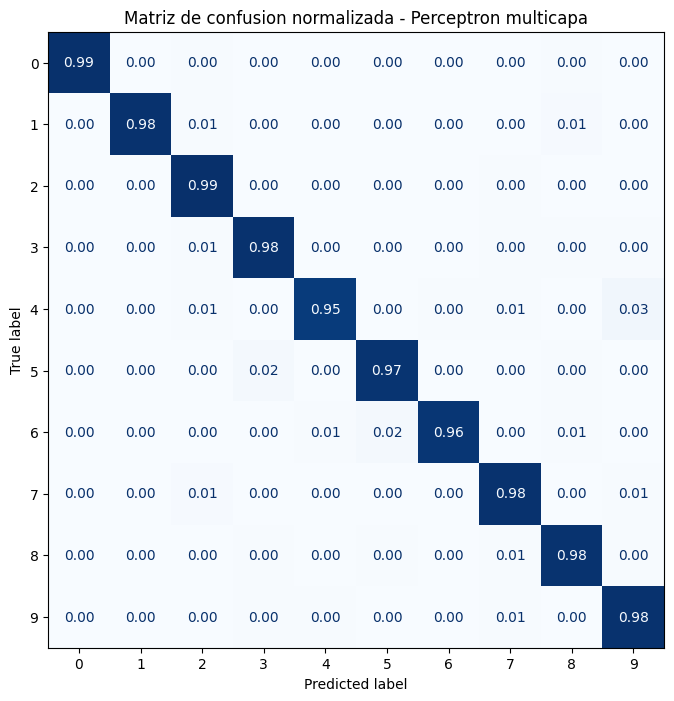

Digitos mas problematicos (menor recall):
- Digito 4: recall=0.9460
- Digito 6: recall=0.9645
- Digito 5: recall=0.9731

Confusiones mas habituales (porcentaje sobre el digito real):
- 4 -> 9: 3.46%
- 6 -> 5: 1.67%
- 5 -> 3: 1.57%
- 7 -> 2: 0.97%
- 1 -> 8: 0.79%
- 4 -> 2: 0.71%
- 1 -> 2: 0.70%
- 9 -> 7: 0.69%


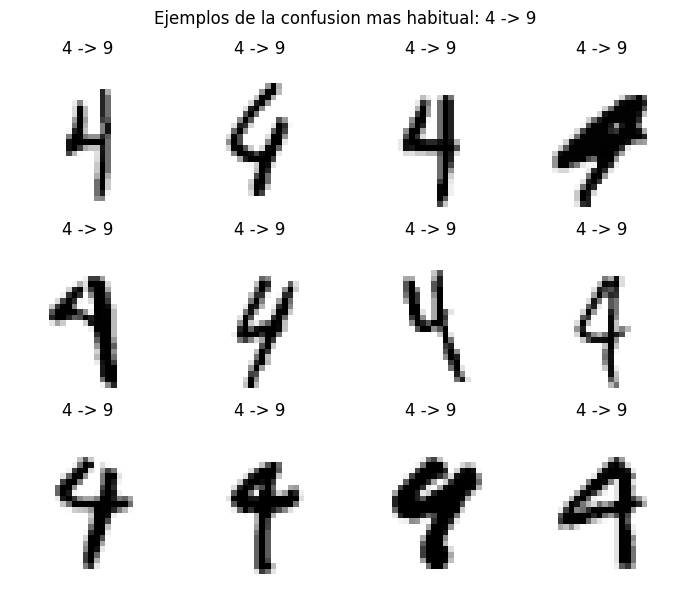

In [23]:
y_pred_test_mlpm = best_mlpm.predict(X_test)

test_acc_mlpm = accuracy_score(y_test, y_pred_test_mlpm)
gap = best_train_acc - best_val_acc

print("Mejores hiperparametros (MLP multicapa):", best_params_mlpm)
print(f"Accuracy CV (validacion): {best_val_acc:.4f}")
print(f"Accuracy train (modelo ganador): {best_train_acc:.4f}")
print(f"Brecha train-validacion: {gap:.4f}")
print(f"Accuracy en test: {test_acc_mlpm:.4f}\n")

print("Informe de clasificacion en test (MLP multicapa):\n")
print(classification_report(y_test, y_pred_test_mlpm, digits=4))

labels = np.array(best_mlpm.classes_)
cm_norm = confusion_matrix(y_test, y_pred_test_mlpm, labels=labels, normalize="true")

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
ax.set_title("Matriz de confusion normalizada - Perceptron multicapa")
plt.show()

recalls = np.diag(cm_norm)
worst_idx = np.argsort(recalls)[:3]
print("Digitos mas problematicos (menor recall):")
for i in worst_idx:
    print(f"- Digito {labels[i]}: recall={recalls[i]:.4f}")


###############################################
# Código generado con inteligencia artificial #
###############################################

cm_off = cm_norm.copy()
np.fill_diagonal(cm_off, 0.0)
pairs = []
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j:
            pairs.append((cm_off[i, j], labels[i], labels[j]))
pairs.sort(key=lambda x: x[0], reverse=True)

print("\nConfusiones mas habituales (porcentaje sobre el digito real):")
for rate, true_label, pred_label in pairs[:8]:
    print(f"- {true_label} -> {pred_label}: {100 * rate:.2f}%")

# Visualizacion de ejemplos reales de la confusion mas frecuente

top_rate, top_true, top_pred = pairs[0]
mask = (y_test == top_true) & (y_pred_test_mlpm == top_pred)
idx = np.where(mask)[0][:12]

if len(idx) > 0:
    fig, axes = plt.subplots(3, 4, figsize=(7, 6))
    for ax, k in zip(axes.ravel(), idx):
        ax.imshow(X_test[k].reshape(28, 28), cmap="gray_r")
        ax.set_title(f"{y_test[k]} -> {y_pred_test_mlpm[k]}")
        ax.axis("off")
    fig.suptitle(f"Ejemplos de la confusion mas habitual: {top_true} -> {top_pred}")
    plt.tight_layout()
    plt.show()

## Conclusiones:

Vemos ahora otra matriz completamente distinta, ahora, todos los números superan ese 90% de acierto en la predicción, de las 10.000 muestras de test, solo predecimos mal 249.

Vemos además que el número que peor recall tiene es el 4, al ver estas 12 muestras de de predicciones erróneas, vemos que es un error muy razonable, dado que ambos números se escriben de manera muy similar, y se parecen a 9s (alguno más que otro).

De todos los hiperparámetros probados, vemos que el mejor ha sido usando 2 capas ocultas de $300$ y $150$ neuronas, al igual que un alfa de $10^{-5}$ y un learning rate de $0.002$
Para los 3 mejores modelos obtenidos en entrenamiento, obtenemos los mejores resultados usando un learning rate de $0.002$, y 2 de ellos tienen un alfa de $10^{-3}$ con 2 y 1 capa de neuronas respectivamente.

### Probamos ahora con 'sdg' también.

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.base import clone
from sklearn.model_selection import ParameterGrid, StratifiedKFold, cross_validate
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

base_mlpm = MLPClassifier(
    activation="relu",
    solver="sgd",
    max_iter=80,
    early_stopping=False,
    validation_fraction=0.1,
    tol=1e-1,
    n_iter_no_change=5,
    random_state=28,
)

param_dist_mlpm = {
    "mlp__hidden_layer_sizes": [(128,), (256,), (128, 64), (256, 128), (300, 150)],
    "mlp__alpha": [1e-5, 1e-4, 5e-4, 1e-3],
    "mlp__learning_rate_init": [5e-4, 1e-3, 2e-3],
}

cv_mlpm = StratifiedKFold(n_splits=3, shuffle=True, random_state=28)

rows_mlpm = []
best_val_acc = -np.inf
best_train_acc = None
best_params_mlpm = None

for params in ParameterGrid(param_dist_mlpm):
    model = Pipeline([("mlp", clone(base_mlpm))])
    model.set_params(**params)
    scores = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv_mlpm,
        scoring="accuracy",
        return_train_score=True,
        n_jobs=-1,
    )

    mean_train = float(np.mean(scores["train_score"]))
    mean_val = float(np.mean(scores["test_score"]))
    rows_mlpm.append({
        "hidden_layers": str(params["mlp__hidden_layer_sizes"]),
        "alpha": float(params["mlp__alpha"]),
        "learning_rate_init": float(params["mlp__learning_rate_init"]),
        "train_accuracy": mean_train,
        "val_accuracy": mean_val,
    })

    if mean_val > best_val_acc:
        best_val_acc = mean_val
        best_train_acc = mean_train
        best_params_mlpm = params

best_mlpm = Pipeline([("mlp", clone(base_mlpm))])
best_mlpm.set_params(**best_params_mlpm)
best_mlpm.fit(X_train, y_train)

cv_results_mlpm_sgd = pd.DataFrame(rows_mlpm)

cv_results_mlpm_sgd.sort_values(by="val_accuracy", ascending=False, inplace=True)
cv_results_mlpm_sgd.head(10)

,hidden_layers,alpha,learning_rate_init,train_accuracy,val_accuracy
59,"(300, 150)",0.00100,0.002,0.930808,0.925817
44,"(300, 150)",0.00050,0.002,0.930867,0.925800
29,"(300, 150)",0.00010,0.002,0.930808,0.925767
14,"(300, 150)",0.00001,0.002,0.930842,0.925767
56,"(256, 128)",0.00100,0.002,0.929017,0.924900
26,"(256, 128)",0.00010,0.002,0.929008,0.924900
41,"(256, 128)",0.00050,0.002,0.928983,0.924883
11,"(256, 128)",0.00001,0.002,0.929000,0.924867
8,"(128, 64)",0.00001,0.002,0.928675,0.924467
38,"(128, 64)",0.00050,0.002,0.928667,0.924450


Mejores hiperparametros (MLP multicapa): {'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (300, 150), 'mlp__learning_rate_init': 0.002}
Accuracy CV (validacion): 0.9258
Accuracy train (modelo ganador): 0.9308
Brecha train-validacion: 0.0050
Accuracy en test: 0.9382

Informe de clasificacion en test (MLP multicapa):

              precision    recall  f1-score   support

           0     0.9430    0.9796    0.9610       980
           1     0.9737    0.9797    0.9767      1135
           2     0.9479    0.9176    0.9325      1032
           3     0.9249    0.9386    0.9317      1010
           4     0.9213    0.9420    0.9315       982
           5     0.9344    0.9103    0.9222       892
           6     0.9341    0.9614    0.9475       958
           7     0.9540    0.9290    0.9414      1028
           8     0.9187    0.9055    0.9121       974
           9     0.9237    0.9118    0.9177      1009

    accuracy                         0.9382     10000
   macro avg     0.9376    0.937

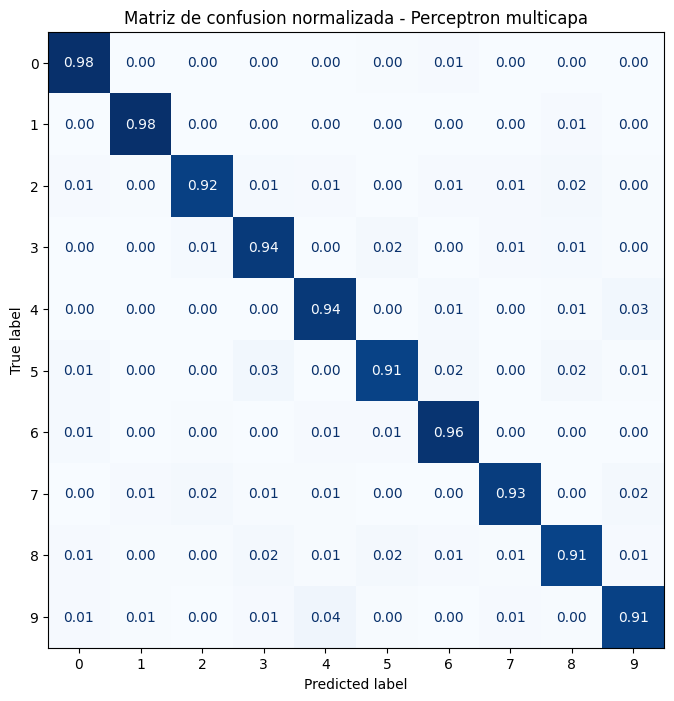

Digitos mas problematicos (menor recall):
- Digito 8: recall=0.9055
- Digito 5: recall=0.9103
- Digito 9: recall=0.9118

Confusiones mas habituales (porcentaje sobre el digito real):
- 9 -> 4: 4.06%
- 4 -> 9: 3.05%
- 5 -> 3: 2.69%
- 7 -> 2: 2.24%
- 8 -> 5: 2.05%
- 7 -> 9: 2.04%
- 8 -> 3: 1.85%
- 2 -> 8: 1.84%


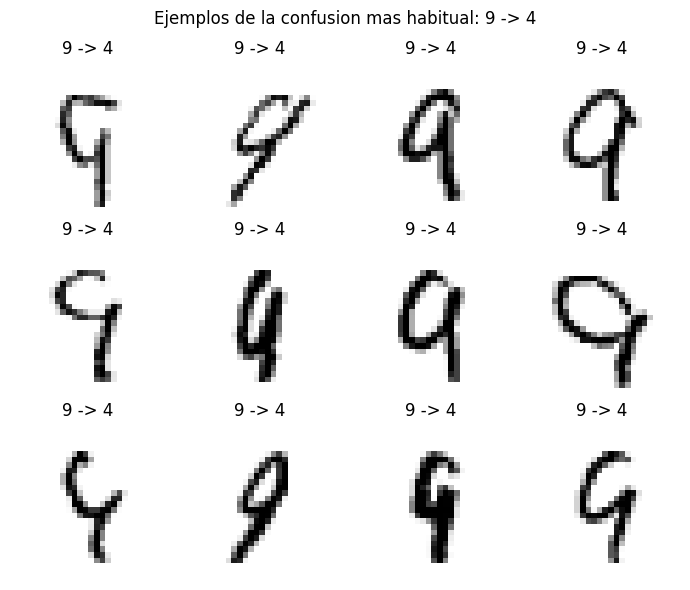

In [25]:
y_pred_test_mlpm = best_mlpm.predict(X_test)

test_acc_mlpm = accuracy_score(y_test, y_pred_test_mlpm)
gap = best_train_acc - best_val_acc

print("Mejores hiperparametros (MLP multicapa):", best_params_mlpm)
print(f"Accuracy CV (validacion): {best_val_acc:.4f}")
print(f"Accuracy train (modelo ganador): {best_train_acc:.4f}")
print(f"Brecha train-validacion: {gap:.4f}")
print(f"Accuracy en test: {test_acc_mlpm:.4f}\n")

print("Informe de clasificacion en test (MLP multicapa):\n")
print(classification_report(y_test, y_pred_test_mlpm, digits=4))

labels = np.array(best_mlpm.classes_)
cm_norm = confusion_matrix(y_test, y_pred_test_mlpm, labels=labels, normalize="true")

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
ax.set_title("Matriz de confusion normalizada - Perceptron multicapa")
plt.show()

recalls = np.diag(cm_norm)
worst_idx = np.argsort(recalls)[:3]
print("Digitos mas problematicos (menor recall):")
for i in worst_idx:
    print(f"- Digito {labels[i]}: recall={recalls[i]:.4f}")


###############################################
# Código generado con inteligencia artificial #
###############################################

cm_off = cm_norm.copy()
np.fill_diagonal(cm_off, 0.0)
pairs = []
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j:
            pairs.append((cm_off[i, j], labels[i], labels[j]))
pairs.sort(key=lambda x: x[0], reverse=True)

print("\nConfusiones mas habituales (porcentaje sobre el digito real):")
for rate, true_label, pred_label in pairs[:8]:
    print(f"- {true_label} -> {pred_label}: {100 * rate:.2f}%")

# Visualizacion de ejemplos reales de la confusion mas frecuente
top_rate, top_true, top_pred = pairs[0]
mask = (y_test == top_true) & (y_pred_test_mlpm == top_pred)
idx = np.where(mask)[0][:12]

if len(idx) > 0:
    fig, axes = plt.subplots(3, 4, figsize=(7, 6))
    for ax, k in zip(axes.ravel(), idx):
        ax.imshow(X_test[k].reshape(28, 28), cmap="gray_r")
        ax.set_title(f"{y_test[k]} -> {y_pred_test_mlpm[k]}")
        ax.axis("off")
    fig.suptitle(f"Ejemplos de la confusion mas habitual: {top_true} -> {top_pred}")
    plt.tight_layout()
    plt.show()

## Conclusiones:
Vemos que para este caso, el solver de *'sgd'* escoge los mismos hiperparámetros que el *'adam'* para su mejor modelo, pero teniendo peores resultados que usando el solver *'adam'*

Vemos también que para este caso, el número 9 es más confundido por el 4, que el 4 por el 9.

Esta diferencia en el modelo está ya contemplada en una página de [Scikit-Learn (ENG)](https://scikit-learn.org/stable/auto_examples/neural_networks/plot_mlp_training_curves.html#sphx-glr-auto-examples-neural-networks-plot-mlp-training-curves-py), que nos indica que la opitimización de *'adam'* hace que la pérdida de entrenamiento sea menor durante el entrenamiento de los datos, aunque esta comprobación se haya hecho en un dataset pequeño, asegura que se puede a aplicar a datasets más grandes, como este.

## 4bis. MLP en PyTorch con inspeccion de gradientes


In [ ]:
# ===============================================
# MLP multicapa en PyTorch + inspeccion de gradientes
# ===============================================
# Este bloque esta pensado para aprendizaje:
# - Entrena una red neuronal sencilla sobre MNIST.
# - Justo despues de loss.backward() y antes de optimizer.step(),
#   inspecciona los gradientes de cada capa.

import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

###############################################
# Código generado con inteligencia artificial #
###############################################


# ------------------------------
# 1) Reproducibilidad
# ------------------------------
SEED = 28
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ------------------------------
# 2) Dispositivo de computo
# ------------------------------
# Si hay GPU (CUDA), se usa. Si no, CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")


# ------------------------------
# 3) Carga de datos (MNIST)
# ------------------------------
# Transformaciones basicas:
# - ToTensor(): convierte imagen PIL [0..255] a tensor [0..1]
# - Normalize(): estandariza usando media y desviacion tipicas de MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# ------------------------------
# 4) Definicion del modelo
# ------------------------------
# MLP sencillo: 784 -> 128 -> 10
# (equivalente conceptual a un MLPClassifier con una capa oculta)
class RedNeuronal(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.aplanar = nn.Flatten()
        self.capa1 = nn.Linear(28 * 28, hidden_dim)
        self.activacion = nn.ReLU()
        self.capa2 = nn.Linear(hidden_dim, 10)

    def forward(self, x):
        x = self.aplanar(x)
        x = self.capa1(x)
        x = self.activacion(x)
        x = self.capa2(x)
        return x


modelo = RedNeuronal(hidden_dim=128).to(device)


# ------------------------------
# 5) Funcion de perdida y optimizador
# ------------------------------
# CrossEntropyLoss combina softmax + NLL internamente.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelo.parameters(), lr=1e-3)


# ------------------------------
# 6) Utilidades para gradientes
# ------------------------------
def estadisticas_gradiente(grad_tensor):
    """
    Devuelve medidas simples para entender el estado del gradiente:
    - mean_abs: media del valor absoluto
    - max_abs: maximo del valor absoluto
    - l2_norm: norma L2 del gradiente
    """
    g = grad_tensor.detach()
    mean_abs = g.abs().mean().item()
    max_abs = g.abs().max().item()
    l2_norm = g.norm(p=2).item()
    return mean_abs, max_abs, l2_norm


# Diccionario para guardar historial de gradientes por capa
hist_grad = {
    "capa1.weight": {"mean_abs": [], "max_abs": [], "l2_norm": []},
    "capa1.bias":   {"mean_abs": [], "max_abs": [], "l2_norm": []},
    "capa2.weight": {"mean_abs": [], "max_abs": [], "l2_norm": []},
    "capa2.bias":   {"mean_abs": [], "max_abs": [], "l2_norm": []},
}


# ------------------------------
# 7) Evaluacion en test
# ------------------------------
def evaluar_accuracy(modelo_eval, loader_eval):
    modelo_eval.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x_batch, y_batch in loader_eval:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits = modelo_eval(x_batch)
            pred = logits.argmax(dim=1)
            correct += (pred == y_batch).sum().item()
            total += y_batch.size(0)
    return correct / total


# ------------------------------
# 8) Bucle de entrenamiento
# ------------------------------
num_epochs = 3
print_every = 100  # cada cuantos batches imprimir gradientes

for epoch in range(1, num_epochs + 1):
    modelo.train()
    running_loss = 0.0

    for batch_idx, (x_batch, y_batch) in enumerate(train_loader, start=1):
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # 1) Limpiar gradientes anteriores acumulados
        optimizer.zero_grad()

        # 2) Forward: salida del modelo
        logits = modelo(x_batch)

        # 3) Calculo de perdida
        loss = criterion(logits, y_batch)

        # 4) Backpropagation: calcula gradientes y los deja en .grad
        loss.backward()

        # ==========================================================
        # 5) INSPECCION DE GRADIENTES (PUNTO CLAVE EDUCATIVO)
        # ==========================================================
        # En este momento:
        # - modelo.capa1.weight.grad ya existe
        # - modelo.capa2.weight.grad ya existe
        # Todavia NO hemos actualizado pesos (optimizer.step no llamado aun).
        # Por tanto, estamos viendo el gradiente "puro" de este batch.
        with torch.no_grad():
            gradientes = {
                "capa1.weight": modelo.capa1.weight.grad,
                "capa1.bias": modelo.capa1.bias.grad,
                "capa2.weight": modelo.capa2.weight.grad,
                "capa2.bias": modelo.capa2.bias.grad,
            }

            for nombre, g in gradientes.items():
                m_abs, mx_abs, l2 = estadisticas_gradiente(g)
                hist_grad[nombre]["mean_abs"].append(m_abs)
                hist_grad[nombre]["max_abs"].append(mx_abs)
                hist_grad[nombre]["l2_norm"].append(l2)

            # Impresion periodica para observar evolucion
            if batch_idx % print_every == 0 or batch_idx == 1:
                print(
                    f"[Epoch {epoch}/{num_epochs} | Batch {batch_idx}/{len(train_loader)}] "
                    f"loss={loss.item():.4f}"
                )
                for nombre in ["capa1.weight", "capa2.weight"]:
                    m_abs = hist_grad[nombre]["mean_abs"][-1]
                    mx_abs = hist_grad[nombre]["max_abs"][-1]
                    l2 = hist_grad[nombre]["l2_norm"][-1]
                    print(
                        f"  grad {nombre:<13} -> "
                        f"mean|g|={m_abs:.6f} | max|g|={mx_abs:.6f} | ||g||2={l2:.6f}"
                    )

        # 6) Actualizar pesos (descenso por gradiente)
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    acc_test = evaluar_accuracy(modelo, test_loader)
    print(f"--> Fin epoch {epoch}: loss_media={avg_loss:.4f} | test_acc={acc_test:.4f}")
    print()


# ------------------------------
# 9) Resumen final de gradientes
# ------------------------------
print("Resumen final (ultimas estadisticas de gradiente por capa):")
for nombre in hist_grad:
    print(
        f"{nombre}: "
        f"mean|g|={hist_grad[nombre]['mean_abs'][-1]:.6f}, "
        f"max|g|={hist_grad[nombre]['max_abs'][-1]:.6f}, "
        f"||g||2={hist_grad[nombre]['l2_norm'][-1]:.6f}"
    )


Dispositivo: cpu


100.0%
100.0%
100.0%
100.0%


[Epoch 1/3 | Batch 1/469] loss=2.3326
  grad capa1.weight  -> mean|g|=0.003051 | max|g|=0.043647 | ||g||2=1.565417
  grad capa2.weight  -> mean|g|=0.011870 | max|g|=0.104609 | ||g||2=0.603316
[Epoch 1/3 | Batch 100/469] loss=0.2607
  grad capa1.weight  -> mean|g|=0.001233 | max|g|=0.016855 | ||g||2=0.612016
  grad capa2.weight  -> mean|g|=0.019262 | max|g|=0.136303 | ||g||2=0.965208
[Epoch 1/3 | Batch 200/469] loss=0.3070
  grad capa1.weight  -> mean|g|=0.001308 | max|g|=0.014764 | ||g||2=0.604547
  grad capa2.weight  -> mean|g|=0.018107 | max|g|=0.173776 | ||g||2=1.063544
[Epoch 1/3 | Batch 300/469] loss=0.2011
  grad capa1.weight  -> mean|g|=0.000951 | max|g|=0.012368 | ||g||2=0.479440
  grad capa2.weight  -> mean|g|=0.011985 | max|g|=0.071874 | ||g||2=0.636842
[Epoch 1/3 | Batch 400/469] loss=0.2184
  grad capa1.weight  -> mean|g|=0.001079 | max|g|=0.014525 | ||g||2=0.513031
  grad capa2.weight  -> mean|g|=0.013523 | max|g|=0.108142 | ||g||2=0.809657
--> Fin epoch 1: loss_media=0.30

## Que vemos en estos gradientes:

Al principio, cuando el error (loss) es muy grande, los gradientes también son altos porque el modelo se equivoca mucho y necesita hacer correcciones grandes en sus pesos. A medida que avanza el entrenamiento y la loss va disminuyendo, vemos que los gradientes se hacen cada vez más pequeños. Esto indica que la red está aprendiendo correctamente y, al acercarse a la solución óptima, cada vez necesita ajustarse menos.

## 5. Mostrar resultados

Mostrar las tablas ya calculadas, sin volver a evaluar modelos.

In [26]:
from IPython.display import Markdown, display


tablas = [
    ("Regresion logistica", "df_cv"),
    ("Perceptron sin capa oculta", "cv_results_mlp0"),
    ("Perceptron multicapa (adam)", "cv_results_mlpm_adam"),
    ("Perceptron multicapa (sgd)", "cv_results_mlpm_sgd"),
]

for titulo, nombre in tablas:
    if nombre in globals():
        display(Markdown(f"### {titulo} (`{nombre}`)"))
        display(globals()[nombre])
    else:
        print(f"{nombre}: no esta en memoria. Ejecuta su seccion correspondiente.")


### Regresion logistica (`df_cv`)

,solver,C,train_accuracy,val_accuracy
3,saga,1.00,0.937683,0.921133
5,saga,10.00,0.939150,0.920700
1,saga,0.01,0.917600,0.912183
2,lbfgs,1.00,0.838200,0.836483
4,lbfgs,10.00,0.838204,0.836450
0,lbfgs,0.01,0.837692,0.835733


### Perceptron sin capa oculta (`cv_results_mlp0`)

,solver,alpha,learning_rate_init,train_accuracy,val_accuracy
6,adam,0.00010,0.005,0.933450,0.918700
2,adam,0.00001,0.005,0.933467,0.918683
10,adam,0.00100,0.005,0.933250,0.918650
8,adam,0.00100,0.001,0.917900,0.912167
0,adam,0.00001,0.001,0.917933,0.912150
4,adam,0.00010,0.001,0.917933,0.912133
11,sgd,0.00100,0.005,0.896817,0.893967
3,sgd,0.00001,0.005,0.896817,0.893967
7,sgd,0.00010,0.005,0.896817,0.893967
1,sgd,0.00001,0.001,0.867433,0.864867


### Perceptron multicapa (adam) (`cv_results_mlpm_adam`)

,hidden_layers,alpha,learning_rate_init,train_accuracy,val_accuracy
14,"(300, 150)",0.00001,0.0020,0.996633,0.975900
56,"(256, 128)",0.00100,0.0020,0.997025,0.975633
50,"(256,)",0.00100,0.0020,0.996675,0.975550
28,"(300, 150)",0.00010,0.0010,0.996742,0.975533
20,"(256,)",0.00010,0.0020,0.996567,0.975483
5,"(256,)",0.00001,0.0020,0.996808,0.975450
44,"(300, 150)",0.00050,0.0020,0.995675,0.975433
13,"(300, 150)",0.00001,0.0010,0.996742,0.975250
43,"(300, 150)",0.00050,0.0010,0.996450,0.975167
35,"(256,)",0.00050,0.0020,0.996650,0.974867


### Perceptron multicapa (sgd) (`cv_results_mlpm_sgd`)

,hidden_layers,alpha,learning_rate_init,train_accuracy,val_accuracy
59,"(300, 150)",0.00100,0.0020,0.930808,0.925817
44,"(300, 150)",0.00050,0.0020,0.930867,0.925800
29,"(300, 150)",0.00010,0.0020,0.930808,0.925767
14,"(300, 150)",0.00001,0.0020,0.930842,0.925767
56,"(256, 128)",0.00100,0.0020,0.929017,0.924900
26,"(256, 128)",0.00010,0.0020,0.929008,0.924900
41,"(256, 128)",0.00050,0.0020,0.928983,0.924883
11,"(256, 128)",0.00001,0.0020,0.929000,0.924867
8,"(128, 64)",0.00001,0.0020,0.928675,0.924467
38,"(128, 64)",0.00050,0.0020,0.928667,0.924450


## Conclusiones pricipales:

Como se ha ido viendo antes, vemos como los mejores modelos de Regresión Logística y de MLP sin capa oculta obtienen los mismos resultados (prácticamente) en validación, ya hemos explicado el porqué, pero bueno, en resumen, es porque ambos se crean una separación lineal entre clases y convergen al mínimo global (tienen convergencia asegurada, cosa que no ocurrirá con las capas ocultas), que está alrededor del 0.93 en entrenamiento.

Sin embargo, al añadir capas ocultas, mejoramos los resultados, la adaptación que hace la optimización de *'adam'* respecto a *'sgd'*, es muy notable, viendo diferencias de 4-5 puntos en el *accuracy*, ocurrencia que también ha sido explicada antes.

## Reflexión / Valoración personal

No se han podido probar todos los hiperparámetros deseados, y la tolerancia ha tenido que ser elevada respecto a valores por defecto, para evitar ejecuciones interminables, el entrenamiento de los modelos con capas ocultas ha sido de una duración de 18-20 minutos, es decir 40 minutos entre *sgd* y *adam*, con las diversas configuraciones de los parámetros que hemos puesto y que se pueden ver en el código.

También me hubiese gustado probar la expansión de atributos, para ver si podía conseguir un modelo de regresión logística algo más competente que el MLP sin capas ocultas, pero cuando probé paré la ejecución del entrenamiento a los +45 minutos.